# Phase 4: Unscaled Electronic Health Records (Dataset 4)

In [1]:
# The hospital administration wants to predict which incoming emergency room patients are at risk for severe sepsis complications. 
# You are given a massive dump of EHR data containing 64 variables. 
# This presents the messy reality of clinical data: heavy class imbalance (90% routine, 10% severe) and wildly unscaled features. 
# Column 3 might be “Age” (0–100), while Column 12 is “White Blood Cell Count” (4000–11000).

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import time

In [6]:
dataset = np.genfromtxt("../PRNN_2026_A1_data/dataset_4.csv", delimiter=",", dtype=float, skip_header=1, filling_values=np.nan)
print(dataset.shape)
print(np.isnan(dataset).any())

(15000, 65)
False


In [7]:
x = dataset[:, :-1]
y = dataset[:, -1:]
print(x.shape, y.shape)

(15000, 64) (15000, 1)


In [8]:
np.random.seed(42)

## 4.12 Multiclass Extension & Scaling:

In [ ]:
# Extend your logistic regression to multiclass using the One-vs-Rest strategy. 
# Run it on the raw Dataset 4. Then, implement a StandardScaler from scratch, apply it to Dataset 4, and run the model again. 
# Report the exact number of iterations required to converge in both scenarios.

In [ ]:
def sigmoid(z):
    z = np.clip(z, -500, 500) # clip to avoid overflow
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, lamda):
    m = X.shape[0]
    epsilon = 1e-15 # to avoid log(0)

    h = sigmoid(X @ w)

    bce_cost = - (1/m) * np.sum(y * np.log(h + epsilon) + (1 - y) * np.log(1 - h + epsilon))
    reg_cost = lamda * (0.5 / m) * np.sum(w[1:]**2) 

    return bce_cost + reg_cost

def gradient_descent(X, y, w_init, lamda, lr = 0.001, epochs = 1000, tolerance = 1e-5):
    m = X.shape[0]
    w = w_init.copy()
    loss_history = []
    
    for i in range(epochs):
        cost = compute_cost(X, y, w, lamda)
        loss_history.append(cost)
        # print(f"Epoch {i} Loss: {cost}")
        
        h = sigmoid(X @ w)
        bce_grad = (1/m) * X.T @ (h - y)
        
        # Regularization gradient
        reg_grad = (lamda / m) * w
        reg_grad[0] = 0 # skipping the bias term
        grad = bce_grad + reg_grad
        
        w = w - lr * grad

        if i > 1 and abs(loss_history[-1] - loss_history[-2]) < tolerance:
            break

    return w, loss_history, i+1

def train_logistic_regression(X, y, total_epochs = 1000, lr = 0.0001, lamda = 0.1, tolerance = 1e-5):
    N = X.shape[0]
    d = X.shape[1]

    X_augmented = np.hstack((np.ones((N, 1)), X))
    w_init = np.zeros((d+1, 1))

    w, loss_history, total_iterations = gradient_descent(X_augmented, y, w_init, lamda, lr, total_epochs)

    return w, loss_history, total_iterations

In [148]:
def standard_scaler(X):
    mean_x = np.mean(x_train, axis=0)
    std_x = np.std(x_train, axis=0)
    return mean_x, std_x

In [ ]:
x_train_raw, y_train, _, _ = get_datasets_4_13(x,y, test_dataset_size = 0, normalize = False)
x_train_standardized, y_train, _, _ = get_datasets_4_13(x,y, test_dataset_size = 0, normalize = True)

y_train = y_train.astype(int)

In [166]:
np.unique(y_train)

array([0, 1])

In [198]:
lamda = 0.001
total_epochs = 10000
lr = 0.01

Model failed to converge after 10000 epochs.


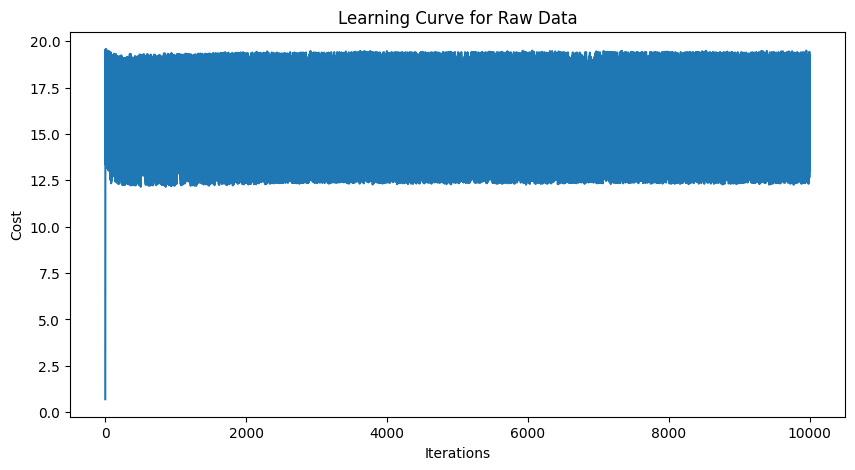

In [200]:
_, loss_history_raw, total_iterations_raw = train_logistic_regression(x_train_raw, y_train, total_epochs = total_epochs, lr = lr, lamda = lamda)
if total_iterations_raw == total_epochs:
    print(f"Model failed to converge after {total_epochs} epochs.")
    
plt.figure(figsize=(10, 5))
plt.plot(range(total_iterations_raw), loss_history_raw)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Learning Curve for Raw Data')
plt.show()

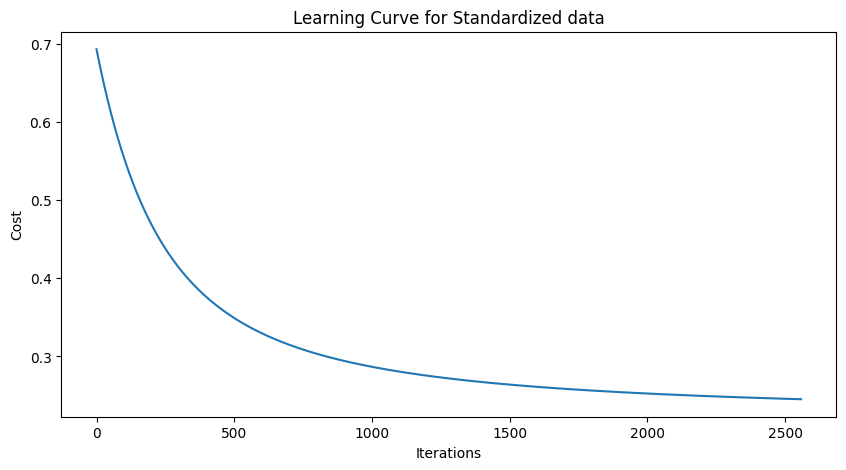

In [ ]:
_, loss_history_std, total_iterations_std = train_logistic_regression(x_train_standardized, y_train, total_epochs = total_epochs, lr = lr, lamda = lamda)
if total_iterations_std == total_epochs:
    print(f"Model failed to converge after {total_epochs} epochs.")

print(f"Toal epochs required to converge: {total_iterations_std}")
plt.figure(figsize=(10, 5))
plt.plot(range(total_iterations_std), loss_history_std)
plt.xlabel('Iterations')
plt.ylabel('Cost')
plt.title('Learning Curve for Standardized data')
plt.show()

## 4.13 Vectorization Benchmarking:

In [5]:
# Implement a K-Nearest Neighbors (KNN) classifier. 
# Write two versions: 
#     1. one that computes pairwise Euclidean distances using nested for loops, and 
#     2. one that uses purely vectorized matrix operations. 
# Time both implementations on a 2,000-sample test split of Dataset 4 and report the speedup factor.

In [149]:
def get_datasets_4_13(x,y, test_dataset_size = 2000, normalize = False):
    N = x.shape[0]
    train_dataset_size = N - test_dataset_size

    idx_arr = np.random.permutation(N)
    train_indices = idx_arr[:train_dataset_size]
    test_indices = idx_arr[train_dataset_size:]

    x_train = x[train_indices]
    y_train = y[train_indices]

    x_test = x[test_indices]
    y_test = y[test_indices]

    if normalize:
        mean_x, std_x = standard_scaler(x_train)
        # std_x[std_x == 0] = 1
        x_train = (x_train - mean_x) / (std_x + 1e-10)
        x_test = (x_test - mean_x) / (std_x + 1e-10)

    return x_train, y_train, x_test, y_test

In [128]:
def knn_classifier_iterative(x_train, x_test, y_train, k = 3):
    N_test = x_test.shape[0]
    N_train = x_train.shape[0]
    y_pred = np.zeros(N_test)

    for i in range(N_test):
        distances = np.empty(N_train)
        for j in range(N_train):
            distances[j] = np.linalg.norm(x_test[i]-x_train[j]) 
        # take k argmin
        # assign y_pred =  majority of y[k argmins]
        k_nns_idx = np.argsort(distances)[:k]
        k_nns_labels = y_train[k_nns_idx].flatten().astype(int)
        pred = np.argmax(np.bincount(k_nns_labels))
        y_pred[i] = pred

    return y_pred

def knn_classifier_vectorized(x_train, x_test, y_train, k = 3):
    N_test = x_test.shape[0]
    N_train = x_train.shape[0]
    y_train_flat = y_train.flatten()

    norm_diff_matrix = calculate_norm_diff_matrix(x_test, x_train) #(N_test, N_train)

    # for each row take k argmin accross the columns for that row
    # assign y_pred =  majority of y[k argmins]
    k_nns_idx = np.argsort(norm_diff_matrix, axis = 1)[:, :k]
    k_nns_labels = y_train_flat[k_nns_idx].reshape(N_test, k).astype(int)
    mode_k_nns_labels = scipy.stats.mode(k_nns_labels, axis=1)
    y_pred = mode_k_nns_labels.mode.flatten()

    return y_pred

def calculate_norm_diff_matrix(X1, X2):
    """
    for each row i of X1, calculates the square norm of differnce between that row and row j of X2
    K[i, j] = ||x_i - x_j||**2 where x_i is the ith row of x1, x_j is the jth row of x2
            = ||x_i||**2 + ||x_j||**2  - 2* x_i.T @ x_j
    """
    x1_norm_sq = np.sum(X1**2, axis=1).reshape(-1, 1) #(N_test, 1)
    x2_norm_sq = np.sum(X2**2, axis=1).reshape(-1, 1) #(N_train, 1)

    K = x1_norm_sq + x2_norm_sq.T - 2 * X1 @ X2.T # (N_test, N_train)

    return K

In [118]:
x_train, y_train, x_test, y_test = get_datasets_4_13(x,y, test_dataset_size = 2000, normalize = False)

In [129]:
start_time = time.perf_counter()

y_pred_iter = knn_classifier_iterative(x_train, x_test, y_train, k = 3)

end_time = time.perf_counter()
elapsed_time_iter = end_time - start_time
print(f"Execution time for iterative approach: {elapsed_time_iter:.4f} seconds")

Execution time for iterative approach: 33.4370 seconds


In [119]:
start_time = time.perf_counter()

y_pred_vec = knn_classifier_vectorized(x_train, x_test, y_train, k = 3)

end_time = time.perf_counter()
elapsed_time_vec = end_time - start_time
print(f"Execution time for vectorized approach: {elapsed_time_vec:.4f} seconds")

Execution time for vectorized approach: 1.3083 seconds


In [131]:
speed_up_factor = elapsed_time_iter / elapsed_time_vec
print(f"Speed up factor: {speed_up_factor:.2f}")

Speed up factor: 25.56


In [136]:
np.sum(y_pred_vec == y_pred_iter)

np.int64(2000)

## 4.14 The Curse of Scale:

In [110]:
# Using your vectorized KNN (K = 5), evaluate the model on both the raw and standardized versions of Dataset 4. 
# Report the exact difference in validation accuracy.

In [111]:
x_train, y_train, x_test, y_test = get_datasets_4_13(x,y, test_dataset_size = 2000, normalize = False)

x_train_standardized, y_train, x_test_standardized, y_test = get_datasets_4_13(x,y, test_dataset_size = 2000, normalize = True)

In [139]:
y_pred_raw = knn_classifier_vectorized(x_train, x_test, y_train, k = 5)
y_pred_std = knn_classifier_vectorized(x_train_standardized, x_test_standardized, y_train, k = 5)

In [147]:
np.sum(y_pred_raw != y_pred_std)

np.int64(70)

In [145]:
test_acc_raw = np.mean(y_pred_raw == y_test)
test_acc_std = np.mean(y_pred_std == y_test)

print(f"Validation Accuracy:")
print(f"    Raw Dataset: {test_acc_raw}")
print(f"    Standardized Dataset: {test_acc_std}")
print(f"Difference in accuracy: {(test_acc_std - test_acc_raw):.6f}")

Validation Accuracy:
    Raw Dataset: 0.877927
    Standardized Dataset: 0.892309
Difference in accuracy: 0.014382


## 4.15 Bayes Optimal & Underflow: 

In [ ]:
# Implement a Naive Bayes classifier with Gaussian Class- conditional densities computing log-probabilities to prevent underflow. 
# Temporarily alter your code to multiply the raw probabilities instead. 
# Report the exact feature dimension D at which the joint probability evaluating Dataset 4 underflows exactly to 0.0 in Python.

In [241]:
def get_class_stats(X, y, classs = 0):
    N = X.shape[0]

    X_classs = X[y.flatten() == classs]
    mean_classs = np.mean(X_classs, axis=0)
    var_classs =np.var(X_classs,  axis=0)
    prior_classs = X_classs.shape[0] / N

    return mean_classs, var_classs, prior_classs

def get_gaussian_log_pdf(X, mean, var):
    return - 0.5 * ( np.log(2 * np.pi * var) + ((X - mean) ** 2) / var )    # (N,)

def get_gaussian_pdf(X, mean, var):
    return ( np.exp(-0.5 * ((X - mean) ** 2) / var) ) / np.sqrt(2 * np.pi * var)    # (N, D)

def naive_bayes_raw(X, y):
    mean_0, var_0, prior_0 = get_class_stats(X, y, classs = 0)
    mean_1, var_1, prior_1 = get_class_stats(X, y, classs = 1)

    posterior_0 = prior_0 * np.prod(get_gaussian_pdf(X, mean_0, var_0), axis=1)
    posterior_1 = prior_1 * np.prod(get_gaussian_pdf(X, mean_1, var_1), axis=1)
    y_pred_raw = posterior_0 < posterior_1  # (N,)

    check_underflow(X, mean_0, var_0, mean_1, var_1)

    return y_pred_raw

def naive_bayes_log(X, y):
    mean_0, var_0, prior_0 = get_class_stats(X, y, classs = 0)
    mean_1, var_1, prior_1 = get_class_stats(X, y, classs = 1)

    log_posterior_0 = np.log(prior_0) + np.sum(get_gaussian_log_pdf(X, mean_0, var_0),axis=1)
    log_posterior_1 = np.log(prior_1) + np.sum(get_gaussian_log_pdf(X, mean_1, var_1),axis=1)
    y_pred_log = log_posterior_0 < log_posterior_1  # (N,)

    return y_pred_log

def check_underflow(X, mean_0, var_0, mean_1, var_1):
    # Find underflow
    D_underflow = None
    for d in range(1, X.shape[1] + 1):
        X_sub = X[:, :d]

        joint_0 = np.prod(get_gaussian_pdf(X_sub, mean_0[:d], var_0[:d]),axis=1)
        joint_1 = np.prod(get_gaussian_pdf(X_sub, mean_1[:d], var_1[:d]),axis=1)

        if np.any(joint_0 == 0.0) or np.any(joint_1 == 0.0):
            D_underflow = d
            break

        if D_underflow is not None:
            break

    if D_underflow is not None:
        print(f"    Raw Joint probability underflows to 0.0 at D = {D_underflow}")
    else:
        print(f"    Raw Joint probability does NOT underflow to 0.0 for any sample up to D = {X.shape[1]}")

In [242]:
np.random.seed(42)
x_nb, y_nb, _, _ = get_datasets_4_13(x, y, test_dataset_size=0, normalize=False)
y_nb_flat = y_nb.flatten()
x_nb = x_nb.astype(np.float32)

# with log-probabilities
print(f"Running Naive Bayes with Log Probabilities..")
y_pred_log = naive_bayes_log(x_nb, y_nb_flat)
acc_log = np.mean(y_pred_log == y_nb_flat)
print(f"    Log-prob accuracy: {acc_log:.4f}\n")

# with raw probabilities
print(f"Running Naive Bayes Raw..")
y_pred_raw_nb = naive_bayes_raw(x_nb, y_nb_flat)
acc_raw = np.mean(y_pred_raw_nb == y_nb_flat)
print(f"    Raw-prob accuracy: {acc_raw:.4f}")

Running Naive Bayes with Log Probabilities..
    Log-prob accuracy: 0.9133

Running Naive Bayes Raw..
    Raw Joint probability underflows to 0.0 at D = 28
    Raw-prob accuracy: 0.8969
